In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data=pd.read_csv("courier_data.csv")

In [5]:
data.describe()


,Shift_Hour,Cumulative_Deliveries,Has_Elevator,Building_Floor,Delay_From_Target_Min,Burnout_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.976800,12.554800,0.687900,5.003600,2.051280,71.507000
std,2.577387,6.902069,0.463374,3.139263,3.993087,20.019256
min,1.000000,1.000000,0.000000,0.000000,-11.900000,16.000000
25%,3.000000,7.000000,0.000000,2.000000,-0.600000,56.000000
50%,5.000000,13.000000,1.000000,5.000000,2.000000,71.000000
75%,7.000000,19.000000,1.000000,8.000000,4.800000,88.000000
max,9.000000,24.000000,1.000000,10.000000,15.900000,100.000000


In [6]:
#Convert categorical text (Traffic_Density) into numerical columns (0 and 1)
df= pd.get_dummies(data, columns=['Traffic_Density'], drop_first=True)

In [7]:
x = df.drop(columns=['Delivery_ID', 'Rider_ID', 'Burnout_Score'])
y = df['Burnout_Score']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
lr=LinearRegression()
rf=RandomForestRegressor(n_estimators=100, random_state=42)

In [10]:
lr_model=lr.fit(x_train,y_train)
rf_model=rf.fit(x_train,y_train)


In [11]:
lr_preds=lr_model.predict(x_test)
rf_preds=rf_model.predict(x_test)

In [12]:
print("--- Linear Regression Performance ---")
print(f"R2 Score: {r2_score(y_test, lr_preds):.4f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f} points")


print("\n--- Random Forest Regressor Performance ---")
print(f"R2 Score: {r2_score(y_test, rf_preds):.4f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f} points")

--- Linear Regression Performance ---
R2 Score: 0.7860
RMSE (Root Mean Squared Error): 9.31 points

--- Random Forest Regressor Performance ---
R2 Score: 0.9517
RMSE (Root Mean Squared Error): 4.42 points


In [13]:
import joblib
joblib.dump(rf_model, 'burnout_rf_model.pkl', compress=3)

['burnout_rf_model.pkl']

In [ ]:
import matplotlib.pyplot as plt

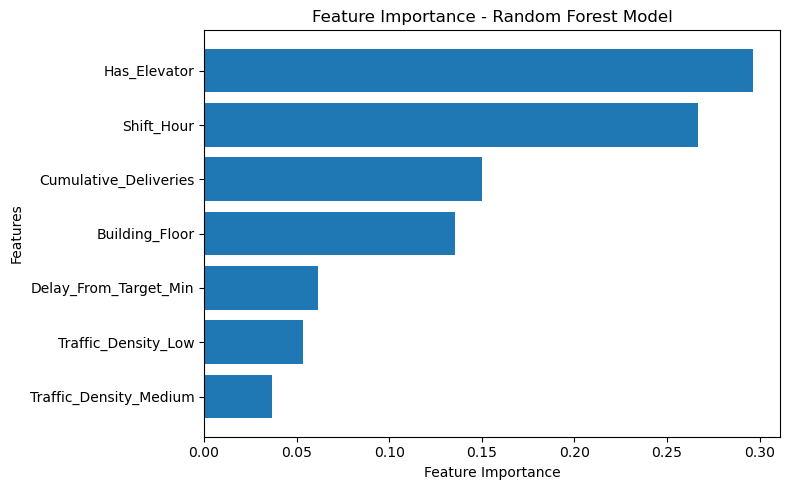

In [19]:

# Feature names
features = x.columns

# Importance values from Random Forest
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest Model")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()